In [3]:
# Import essential models and functions from sklearn
from sklearn.linear_model import LinearRegression, LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
sb.set()
np.random.seed(42)

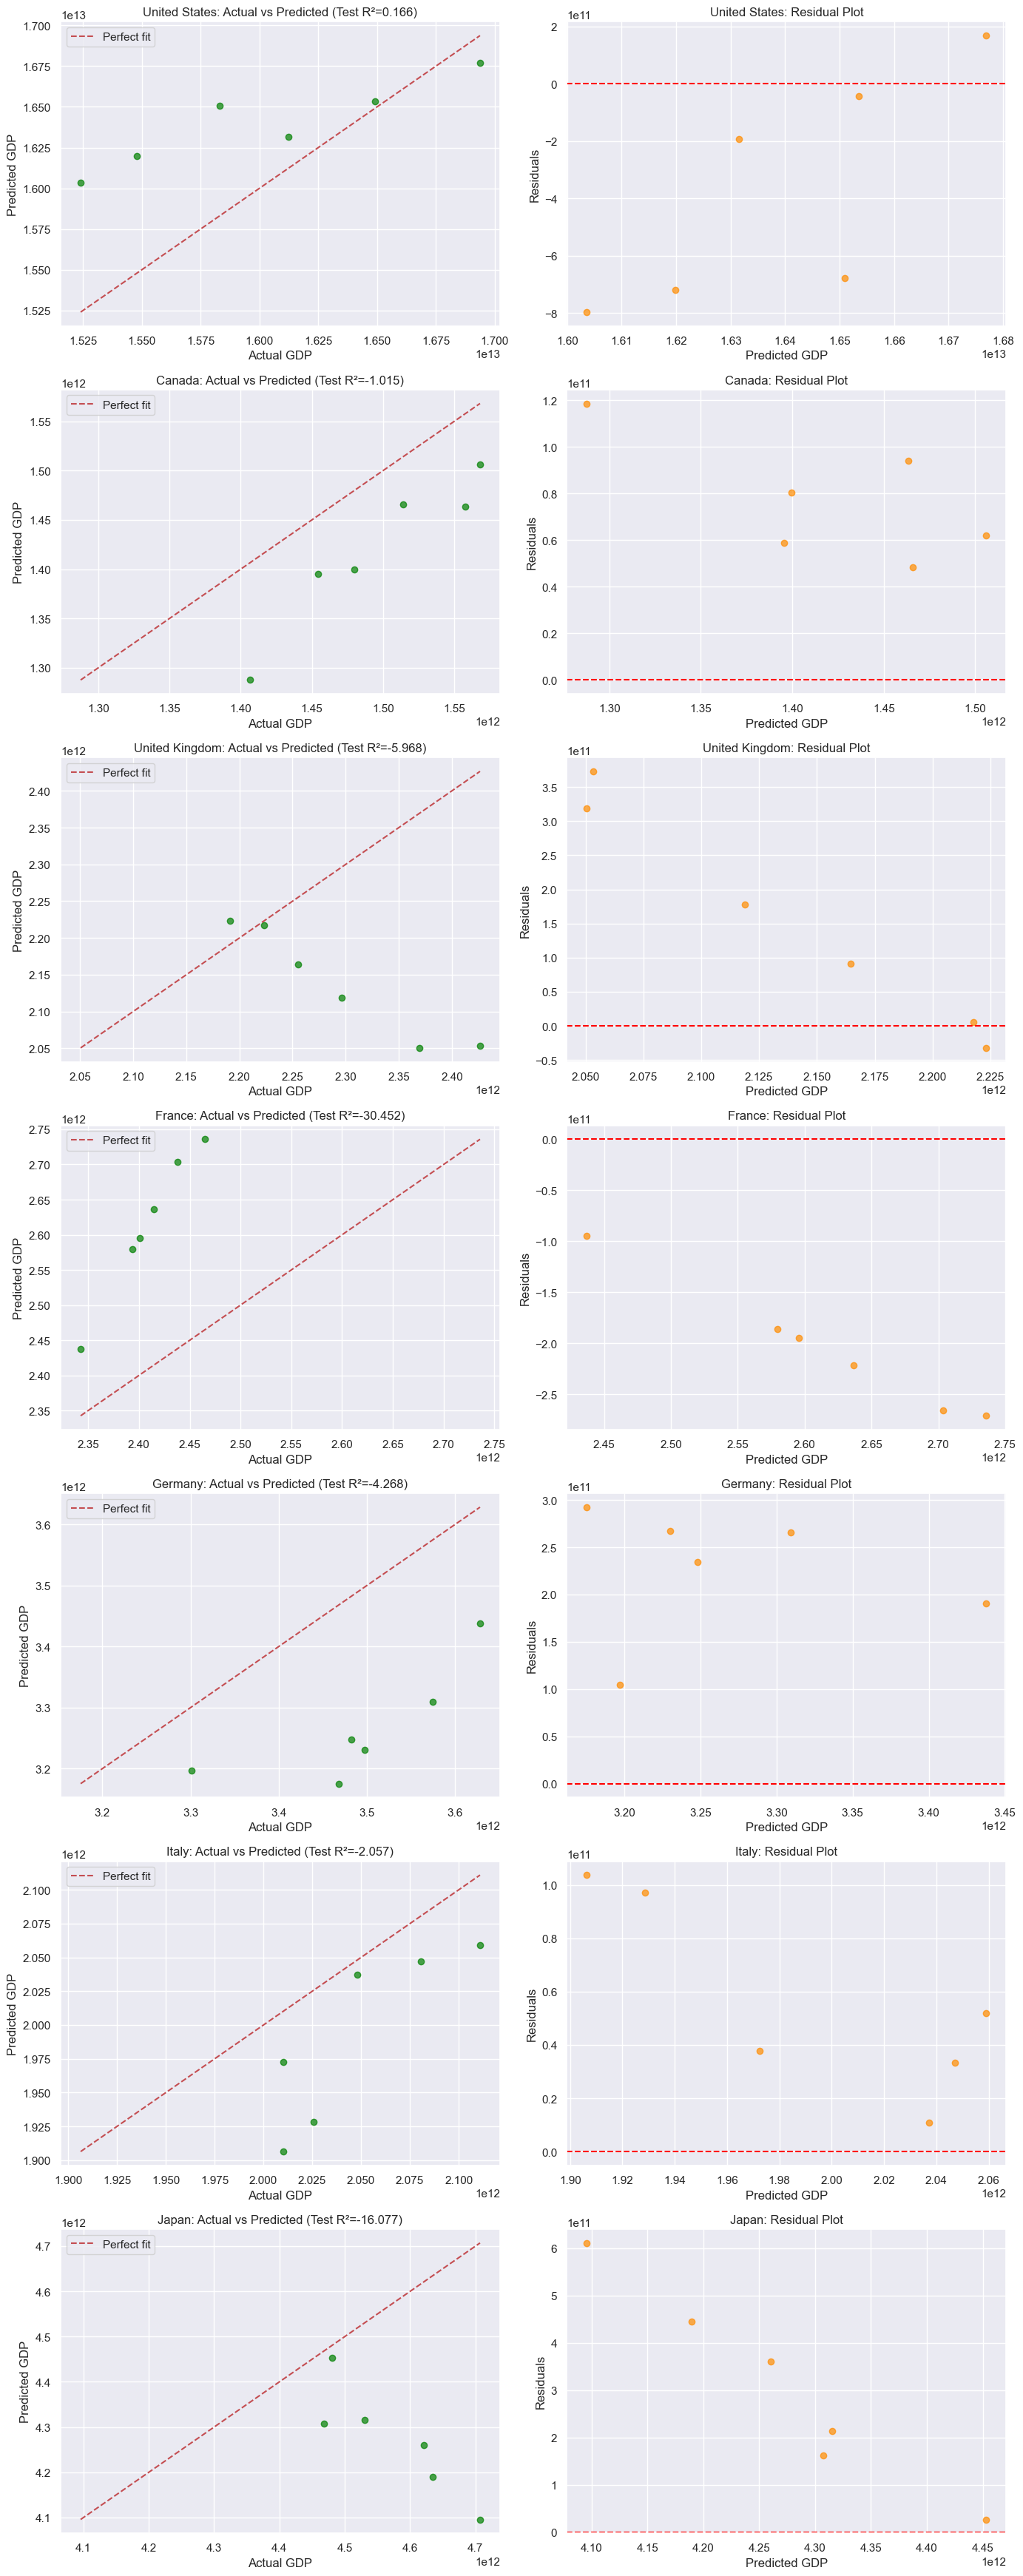

          country  n_train  n_test  train_r2  test_r2      test_mse
0   United States       25       6    0.9272   0.1656  2.799943e+23
1          Canada       25       6    0.8952  -1.0146  6.505846e+21
2  United Kingdom       25       6    0.9795  -5.9677  4.697098e+22
3          France       25       6    0.9756 -30.4525  4.574720e+22
4         Germany       25       6    0.9693  -4.2677  5.488136e+22
5           Italy       25       6    0.9947  -2.0570  4.260067e+21
6           Japan       25       6    0.9813 -16.0772  1.291313e+23


In [4]:
#--------------------------------------------------------
# Version 1: 2 features
#--------------------------------------------------------
d1 = pd.read_csv('owid-energy-data.csv')
d1 = d1.sort_values(["country", "year"])

g7_countries = ["United States", "Canada", "United Kingdom", "France", "Germany", "Italy", "Japan"]
model_features = ["electricity_generation", "energy_per_capita"]
target_col = "gdp"

results = []
country_models = {}

fig, axes = plt.subplots(len(g7_countries), 2, figsize=(14, 5 * len(g7_countries)))

for i, country in enumerate(g7_countries):
    country_df = d1[d1["country"] == country][["year"] + model_features + [target_col]]
    country_df = country_df.dropna()

    train_df = country_df[country_df["year"] < 2010]
    test_df  = country_df[(country_df["year"] >= 2010) & (country_df["year"] <= 2015)]

    if len(train_df) < 3 or len(test_df) < 1:
        print(f"Skipping {country}: insufficient data (train={len(train_df)}, test={len(test_df)})")
        axes[i, 0].set_visible(False)
        axes[i, 1].set_visible(False)
        continue

    X_train, y_train = train_df[model_features], train_df[target_col]
    X_test, y_test   = test_df[model_features], test_df[target_col]

    linreg = LinearRegression()
    linreg.fit(X_train, y_train)

    train_r2 = linreg.score(X_train, y_train)
    test_r2  = linreg.score(X_test, y_test)
    pred_test = linreg.predict(X_test)
    test_mse = mean_squared_error(y_test, pred_test)

    results.append({
        "country": country, "n_train": len(train_df), "n_test": len(test_df),
        "train_r2": round(train_r2, 4), "test_r2": round(test_r2, 4), "test_mse": test_mse
    })
    country_models[country] = linreg

    # --- Actual vs Predicted (test) ---
    axes[i, 0].scatter(y_test, pred_test, alpha=0.7, color="green")
    lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    axes[i, 0].plot(lims, lims, 'r--', label="Perfect fit")
    axes[i, 0].set_xlabel("Actual GDP")
    axes[i, 0].set_ylabel("Predicted GDP")
    axes[i, 0].set_title(f"{country}: Actual vs Predicted (Test R²={test_r2:.3f})")
    axes[i, 0].legend()

    # --- Residual plot (test) ---
    residuals = y_test - pred_test
    axes[i, 1].scatter(pred_test, residuals, alpha=0.7, color="darkorange")
    axes[i, 1].axhline(0, color="red", linestyle="--")
    axes[i, 1].set_xlabel("Predicted GDP")
    axes[i, 1].set_ylabel("Residuals")
    axes[i, 1].set_title(f"{country}: Residual Plot")

plt.tight_layout()
plt.savefig("g7_2features_diagnostics.png", dpi=150)
plt.show()

results_df = pd.DataFrame(results)
print(results_df)

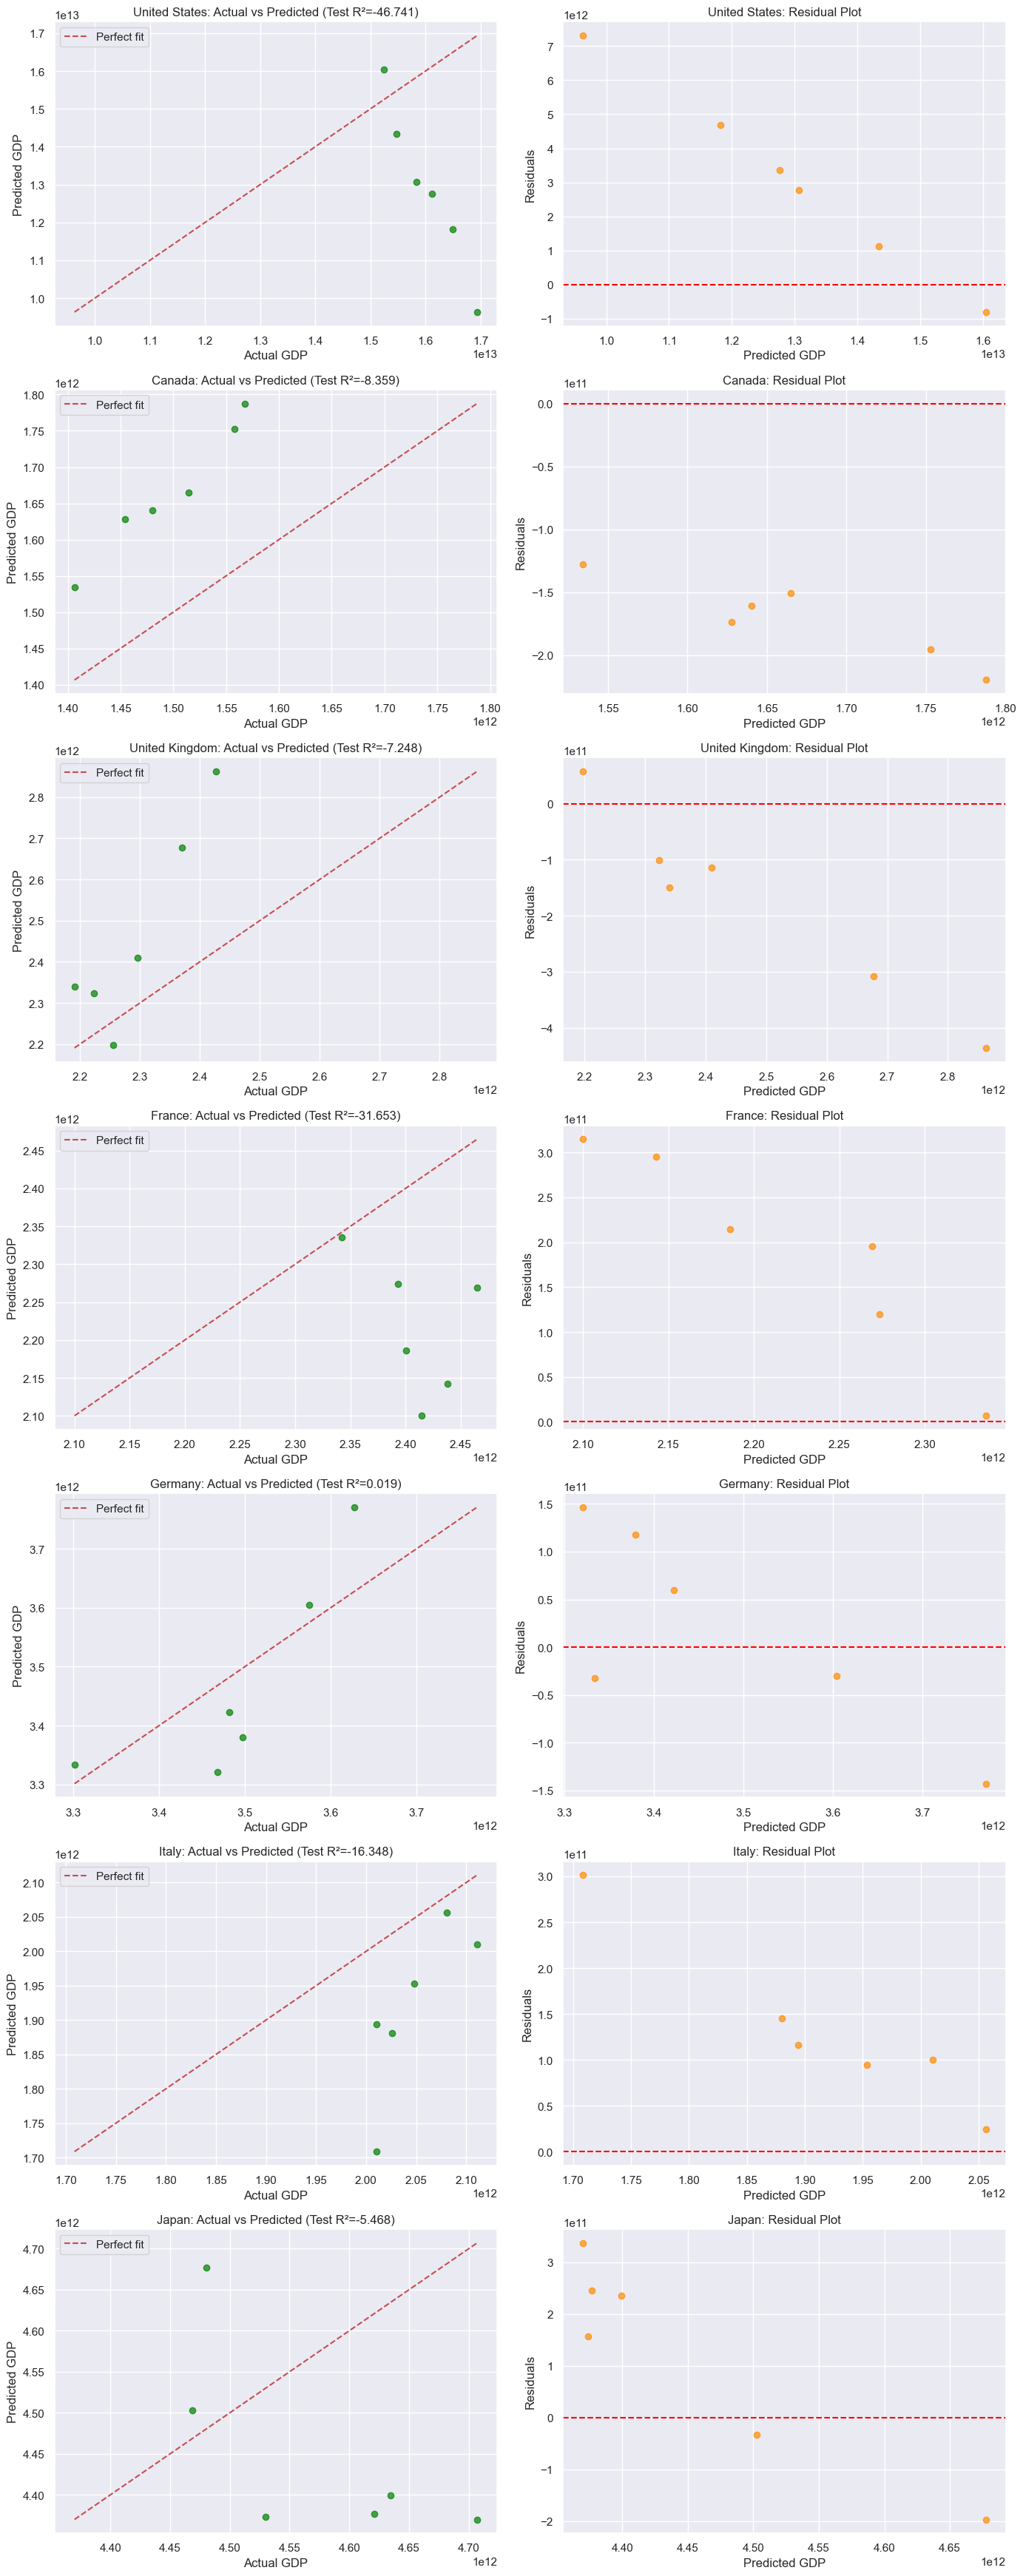

          country  n_train  n_test  train_r2  test_r2      test_mse
0   United States       25       6    0.8517 -46.7414  1.601982e+25
1          Canada       25       6    0.8844  -8.3594  3.022501e+22
2  United Kingdom       25       6    0.9343  -7.2483  5.560327e+22
3          France       25       6    0.8966 -31.6532  4.749365e+22
4         Germany       25       6    0.9765   0.0187  1.022364e+22
5           Italy       25       6    0.9361 -16.3478  2.417490e+22
6           Japan       25       6    0.9214  -5.4675  4.890486e+22


In [6]:
#--------------------------------------------------------
# Version 2: 4 features
#--------------------------------------------------------
d1 = pd.read_csv('owid-energy-data.csv')
d1 = d1.sort_values(["country", "year"])

g7_countries = ["United States", "Canada", "United Kingdom", "France", "Germany", "Italy", "Japan"]
model_features = ["renewables_share_energy", "coal_share_energy", "nuclear_share_energy", "renewables_share_elec"]
target_col = "gdp"

results = []
country_models = {}

fig, axes = plt.subplots(len(g7_countries), 2, figsize=(14, 5 * len(g7_countries)))

for i, country in enumerate(g7_countries):
    country_df = d1[d1["country"] == country][["year"] + model_features + [target_col]]
    country_df = country_df.dropna()

    train_df = country_df[country_df["year"] < 2010]
    test_df  = country_df[(country_df["year"] >= 2010) & (country_df["year"] <= 2015)]

    if len(train_df) < 3 or len(test_df) < 1:
        print(f"Skipping {country}: insufficient data (train={len(train_df)}, test={len(test_df)})")
        axes[i, 0].set_visible(False)
        axes[i, 1].set_visible(False)
        continue

    X_train, y_train = train_df[model_features], train_df[target_col]
    X_test, y_test   = test_df[model_features], test_df[target_col]

    linreg = LinearRegression()
    linreg.fit(X_train, y_train)

    train_r2 = linreg.score(X_train, y_train)
    test_r2  = linreg.score(X_test, y_test)
    pred_test = linreg.predict(X_test)
    test_mse = mean_squared_error(y_test, pred_test)

    results.append({
        "country": country, "n_train": len(train_df), "n_test": len(test_df),
        "train_r2": round(train_r2, 4), "test_r2": round(test_r2, 4), "test_mse": test_mse
    })
    country_models[country] = linreg

    # --- Actual vs Predicted (test) ---
    axes[i, 0].scatter(y_test, pred_test, alpha=0.7, color="green")
    lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    axes[i, 0].plot(lims, lims, 'r--', label="Perfect fit")
    axes[i, 0].set_xlabel("Actual GDP")
    axes[i, 0].set_ylabel("Predicted GDP")
    axes[i, 0].set_title(f"{country}: Actual vs Predicted (Test R²={test_r2:.3f})")
    axes[i, 0].legend()

    # --- Residual plot (test) ---
    residuals = y_test - pred_test
    axes[i, 1].scatter(pred_test, residuals, alpha=0.7, color="darkorange")
    axes[i, 1].axhline(0, color="red", linestyle="--")
    axes[i, 1].set_xlabel("Predicted GDP")
    axes[i, 1].set_ylabel("Residuals")
    axes[i, 1].set_title(f"{country}: Residual Plot")

plt.tight_layout()
plt.savefig("g7_2features_diagnostics.png", dpi=150)
plt.show()

results_df = pd.DataFrame(results)
print(results_df)

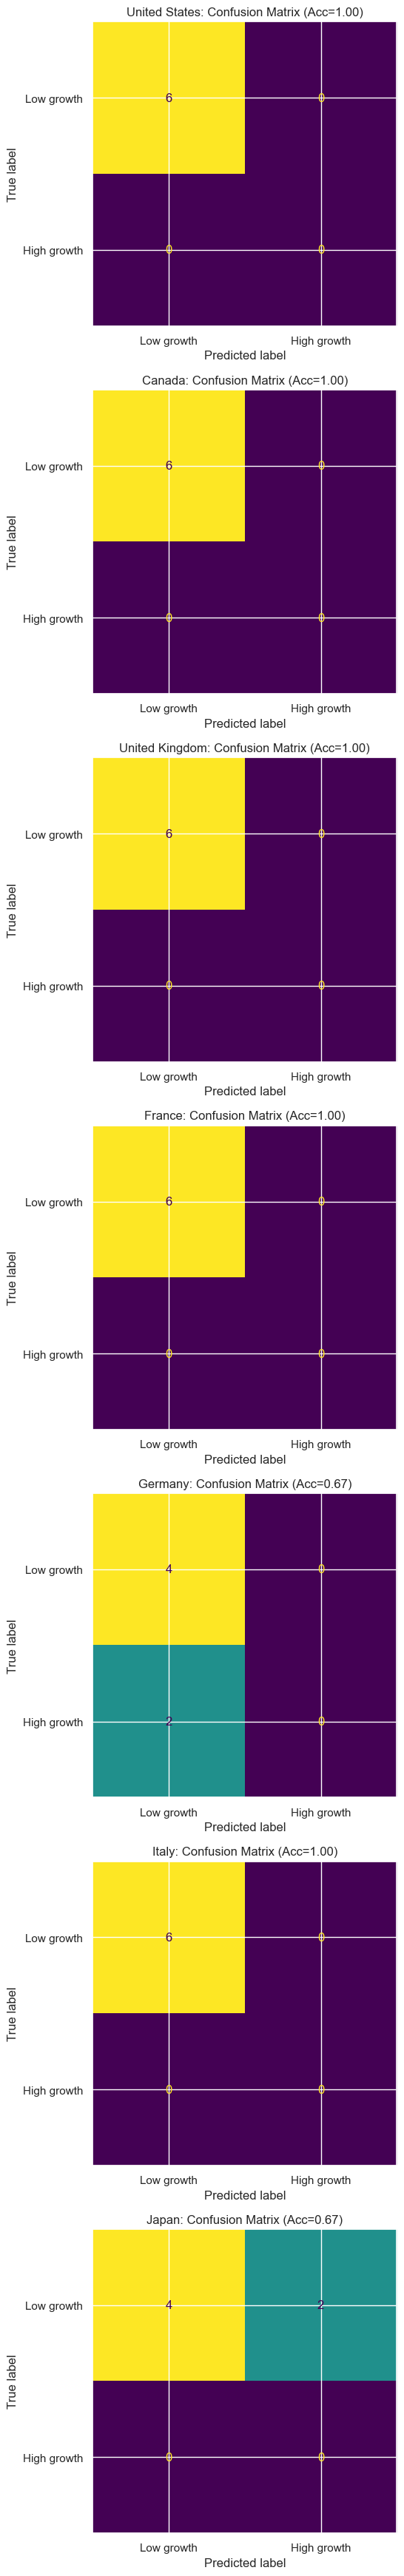

          country  n_train  n_test  accuracy  precision  recall   f1
0   United States       25       6    1.0000        0.0     0.0  0.0
1          Canada       25       6    1.0000        0.0     0.0  0.0
2  United Kingdom       25       6    1.0000        0.0     0.0  0.0
3          France       25       6    1.0000        0.0     0.0  0.0
4         Germany       25       6    0.6667        0.0     0.0  0.0
5           Italy       25       6    1.0000        0.0     0.0  0.0
6           Japan       25       6    0.6667        0.0     0.0  0.0


In [13]:
#--------------------------------------------------------
# Version 1b: 2 features, Logistic Regression (binary growth label)
#--------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

d1 = pd.read_csv('owid-energy-data.csv')
d1 = d1.sort_values(["country", "year"])

# Build a year-over-year growth label, same logic as your uploaded notebook's Cell 2
d1["gdp_growth"] = d1.groupby("country")["gdp"].pct_change(fill_method=None)
d1["growth_median_year"] = d1.groupby("year")["gdp_growth"].transform("median")
d1["growth_label"] = np.where(d1["gdp_growth"] > d1["growth_median_year"], 1, 0)
d1.loc[d1["gdp_growth"].isna(), "growth_label"] = np.nan

g7_countries = ["United States", "Canada", "United Kingdom", "France", "Germany", "Italy", "Japan"]
model_features = ["electricity_generation", "energy_per_capita"]
target_col = "growth_label"

results = []
country_models = {}
fig, axes = plt.subplots(len(g7_countries), 1, figsize=(7, 5 * len(g7_countries)))

for i, country in enumerate(g7_countries):
    country_df = d1[d1["country"] == country][["year"] + model_features + [target_col]]
    country_df = country_df.dropna()

    train_df = country_df[country_df["year"] < 2010]
    test_df  = country_df[(country_df["year"] >= 2010) & (country_df["year"] <= 2015)]

    # Logistic Regression needs BOTH classes present in train and test to work/evaluate meaningfully
    if len(train_df) < 5 or len(test_df) < 1 or train_df[target_col].nunique() < 2:
        print(f"Skipping {country}: insufficient data or single-class only (train={len(train_df)}, test={len(test_df)})")
        axes[i].set_visible(False)
        continue

    X_train, y_train = train_df[model_features], train_df[target_col].astype(int)
    X_test, y_test   = test_df[model_features], test_df[target_col].astype(int)

    logreg = LogisticRegression(max_iter=1000)
    logreg.fit(X_train, y_train)
    pred_test = logreg.predict(X_test)

    acc = accuracy_score(y_test, pred_test)
    prec = precision_score(y_test, pred_test, zero_division=0)
    rec = recall_score(y_test, pred_test, zero_division=0)
    f1 = f1_score(y_test, pred_test, zero_division=0)

    results.append({
        "country": country, "n_train": len(train_df), "n_test": len(test_df),
        "accuracy": round(acc, 4), "precision": round(prec, 4),
        "recall": round(rec, 4), "f1": round(f1, 4)
    })
    country_models[country] = logreg

    cm = confusion_matrix(y_test, pred_test, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["Low growth", "High growth"]).plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f"{country}: Confusion Matrix (Acc={acc:.2f})")

plt.tight_layout()
plt.savefig("g7_2features_logreg_diagnostics.png", dpi=150)
plt.show()

results_df = pd.DataFrame(results)
print(results_df)

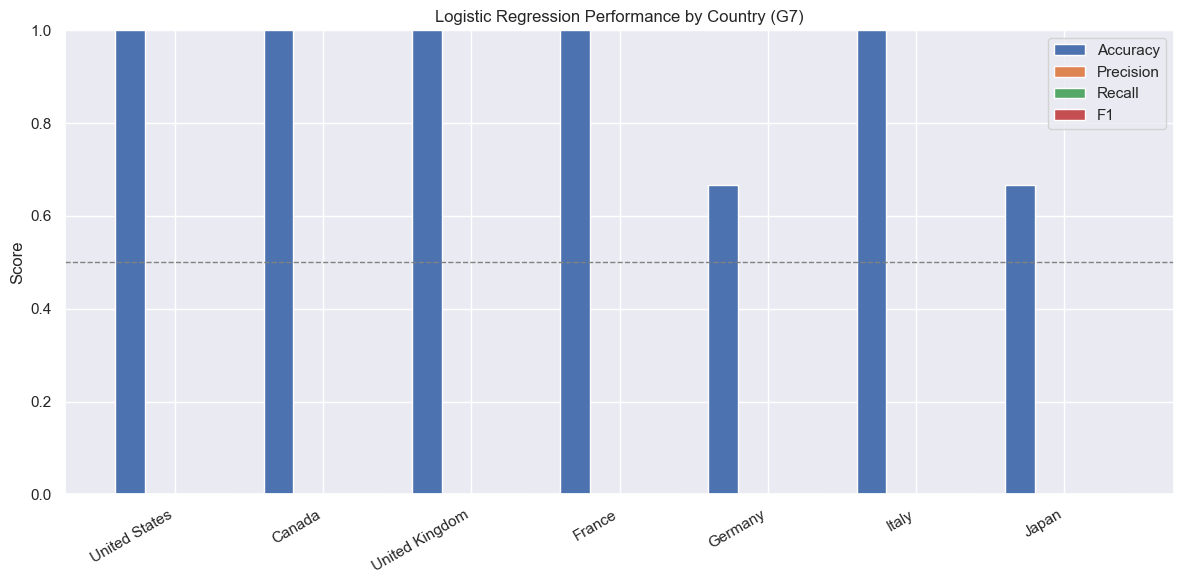

In [6]:
#--------------------------------------------------------
# Summary bar chart across G7 countries
#--------------------------------------------------------
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))  # one position per country
width = 0.2  # width of each bar, narrow enough to fit 4 side-by-side per country

for j, metric in enumerate(metrics_to_plot):
    ax.bar(x + j * width, results_df[metric], width, label=metric.capitalize())

ax.set_xticks(x + width * 1.5)  # center the tick labels under the grouped bars
ax.set_xticklabels(results_df["country"], rotation=30, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Logistic Regression Performance by Country (G7)")
ax.legend()
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance level")

plt.tight_layout()
plt.savefig("g7_2features_logreg_summary.png", dpi=150)
plt.show()

In [14]:
print(pred_test)  # for any one country's test predictions
print(y_test.values)  # compare against actual labels

[0 0 0 0 1 1]
[0 0 0 0 0 0]
